# TEKNOFEST Robolig AI — Demo Notebook

Bu notebook, `RoboligDetector` API'sini test etmek için kullanılır.

**Gereksinimler:** Notebook'u workspace root'tan çalıştırın:
```
cd teknofest-robolig-ai/
jupyter notebook notebooks/demo.ipynb
```

In [1]:
%cd ..

/home/bismih/projelerimiz6/hane-i_kesf/.distrobox/projelerimiz7/teknofest-robolig-ai


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from src.api import RoboligDetector

print("Kütüphane hazır.")

Kütüphane hazır.


## 1. Dedektörü Oluştur

Temel parametreler constructor'dan ayarlanabilir; geri kalan tüm ayarlar `config/` klasöründeki YAML dosyalarından okunur.

In [3]:
detector = RoboligDetector(
    config_dir="config/",
    device="cuda",       # GPU için: "cuda"
    confidence=0.3,     # Güven eşiği
)
print("Dedektör hazır.")

Kalibrasyon dosyası bulunamadı: camera_calibration.npz


Dedektör hazır.


## 2. Test Görüntüsü Yükle

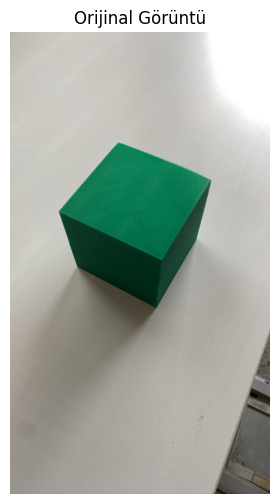

Boyut: (1600, 900, 3)


In [4]:
from pathlib import Path

image_path = Path("data/test_images/cube_01.jpeg")
image = cv2.imread(str(image_path))

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Orijinal Görüntü")
plt.axis("off")
plt.show()
print(f"Boyut: {image.shape}")

## 3. Tespit + Görselleştirme (`detect_and_visualize`)

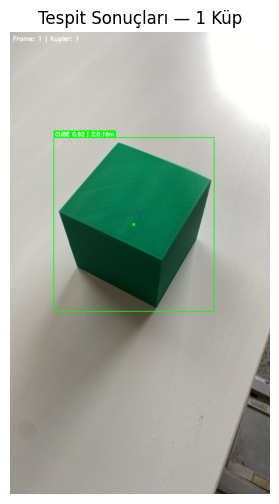

In [5]:
result, annotated = detector.detect_and_visualize(image)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title(f"Tespit Sonuçları — {len(result.cubes)} Küp")
plt.axis("off")
plt.show()

## 4. Sonuçları İncele

In [6]:
print(f"Frame ID   : {result.frame_id}")
print(f"Timestamp  : {result.timestamp:.3f}s")
print(f"Küp sayısı : {len(result.cubes)}")
print()

for i, cube in enumerate(result.cubes):
    print(f"  Küp {i + 1}:")
    b = cube.detection.bbox
    print(f"    BBox        : ({b.x1},{b.y1}) → ({b.x2},{b.y2})  [{b.width}×{b.height}px]")
    print(f"    Güven       : {cube.detection.confidence:.3f}")
    if cube.pose:
        p, o = cube.pose.position, cube.pose.orientation
        print(f"    3D Konum    : x={p.x * 100:.1f}cm  y={p.y * 100:.1f}cm  z={p.z * 100:.1f}cm")
        print(f"    Orientasyon : yaw={o.yaw:.1f}°  pitch={o.pitch:.1f}°  roll={o.roll:.1f}°")
    else:
        print("    Pose        : yok")

Frame ID   : 1
Timestamp  : 1779042023.743s
Küp sayısı : 1

  Küp 1:
    BBox        : (151,365) → (706,967)  [555×602px]
    Güven       : 0.919
    3D Konum    : x=-1.1cm  y=-3.0cm  z=15.6cm
    Orientasyon : yaw=24.0°  pitch=4.7°  roll=2.5°


## 5. Ayrı Adımlarla Kullanım

Tespit: 1 küp


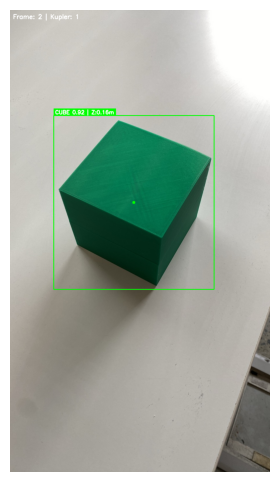

In [7]:
# Sadece tespit
result = detector.detect(image)
print(f"Tespit: {len(result.cubes)} küp")

# Sonradan görselleştir
annotated = detector.visualize(image, result)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## 6. Config Override Örneği

In [8]:
# YAML'dan farklı derinlik aralığı kullanmak için:
detector_custom = RoboligDetector(
    config_dir="config/",
    confidence=0.4,
    config_overrides={
        "pose.pnp.min_depth_m": 0.1,
        "pose.pnp.max_depth_m": 5.0,
    }
)
result_custom, annotated_custom = detector_custom.detect_and_visualize(image)
print(f"Custom config ile tespit: {len(result_custom.cubes)} küp")

Kalibrasyon dosyası bulunamadı: camera_calibration.npz


Custom config ile tespit: 1 küp


## 7. Toplu İşleme

In [9]:
test_dir = Path("data/test_images")
image_paths = sorted(test_dir.glob("*.jpg"))[:4] if test_dir.exists() else []

if image_paths:
    fig, axes = plt.subplots(1, len(image_paths), figsize=(5 * len(image_paths), 5))
    if len(image_paths) == 1:
        axes = [axes]
    for ax, img_path in zip(axes, image_paths):
        img = cv2.imread(str(img_path))
        res, ann = detector.detect_and_visualize(img)
        ax.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{img_path.name}\n{len(res.cubes)} küp")
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("data/test_images/ klasöründe .jpg görüntü bulunamadı.")

data/test_images/ klasöründe .jpg görüntü bulunamadı.
